# Clase de Redes Neuronales Convolucionales (CNN)

## Parte 2: Implementación en TensorFlow/Keras — LeNet-5 con MNIST

**Objetivos de esta sección:**

1. Verificar la **GPU disponible en Colab**.
2. Cargar y preprocesar el dataset **MNIST**.
3. Implementar **LeNet-5** con la API `Sequential` de Keras.
4. Entrenar con **pocas épocas** usando GPU.
5. Evaluar el modelo y **visualizar filtros aprendidos**.
6. Analizar los resultados y comparar con la teoría de la Parte 1.

---

## 1. Verificación del entorno y GPU

Antes de empezar, verificamos que Colab tiene GPU disponible. Si no, ve a:

**Runtime → Change runtime type → Hardware accelerator → T4 GPU**

In [1]:
# ============ CELDA 1: Verificar GPU ============
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Configurar crecimiento de memoria (evita reservar toda la GPU de golpe)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth configurado correctamente.")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No hay GPU. Ve a Runtime → Change runtime type → T4 GPU")

TensorFlow version: 2.20.0
GPU disponible: []
⚠️ No hay GPU. Ve a Runtime → Change runtime type → T4 GPU


---

## 2. Carga y preprocesamiento de MNIST

### 2.1 El dataset MNIST

- **60,000 imágenes de entrenamiento** y **10,000 de test**.
- Imágenes de **$28 \times 28$ píxeles** en escala de grises.
- **10 clases** (dígitos del 0 al 9).
- Valores de píxeles entre 0 y 255.

### 2.2 Preprocesamiento necesario

1. **Normalizar** los píxeles a $[0, 1]$ dividiendo por 255.
2. **Añadir dimensión de canal**: de $(N, 28, 28)$ a $(N, 28, 28, 1)$.
3. **One-hot encoding** de las etiquetas: de entero a vector de 10 dimensiones.

In [2]:
# ============ CELDA 2: Cargar MNIST ============
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Forma original de X_train:", X_train.shape)
print("Forma original de y_train:", y_train.shape)
print("Rango de píxeles:", X_train.min(), "a", X_train.max())
print("Clases únicas:", np.unique(y_train))

Forma original de X_train: (60000, 28, 28)
Forma original de y_train: (60000,)
Rango de píxeles: 0 a 255
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


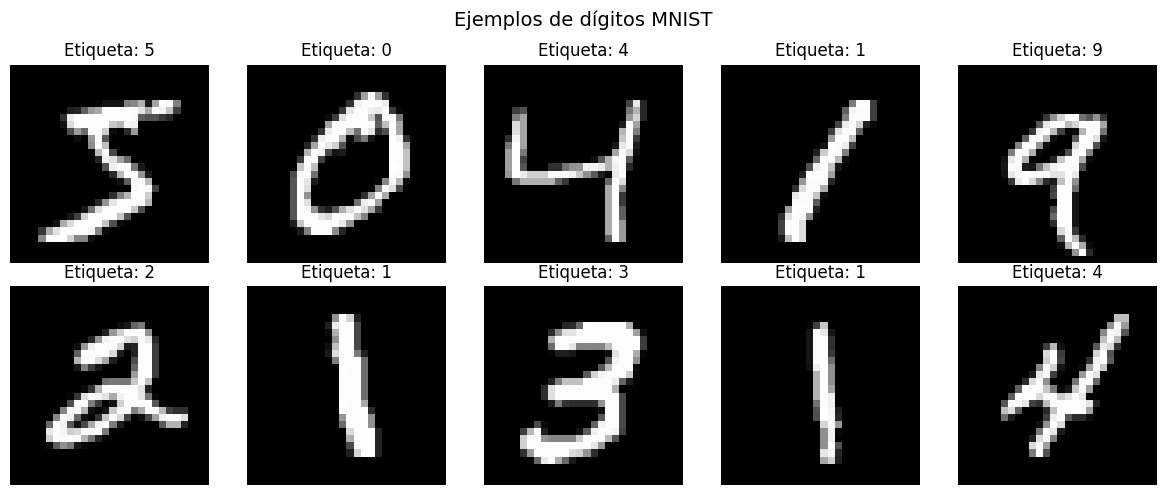

In [3]:
# ============ CELDA 3: Visualizar algunas imágenes ============
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Etiqueta: {y_train[i]}")
    ax.axis('off')
plt.suptitle('Ejemplos de dígitos MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# ============ CELDA 4: Preprocesamiento ============
# 1. Normalizar a [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Añadir canal: (N, 28, 28) -> (N, 28, 28, 1)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# 3. One-hot encoding de etiquetas
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("X_train:", X_train.shape, "| rango:", X_train.min(), "a", X_train.max())
print("y_train:", y_train.shape, "| ejemplo:", y_train[0])

X_train: (60000, 28, 28, 1) | rango: 0.0 a 1.0
y_train: (60000, 10) | ejemplo: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


---

## 3. Implementación de LeNet-5 en Keras

### 3.1 Recordatorio de la arquitectura (Parte 1)

Para MNIST ($28\times28$) adaptamos LeNet-5 usando `padding='same'` en la primera convolución:

| Capa | Tipo | Configuración | Salida |
|------|------|---------------|--------|
| Entrada | — | — | $28 \times 28 \times 1$ |
| C1 | Conv2D | 6 filtros $5\times5$, `same`, tanh | $28 \times 28 \times 6$ |
| S2 | AvgPool | $2\times2$, stride=2 | $14 \times 14 \times 6$ |
| C3 | Conv2D | 16 filtros $5\times5$, `valid`, tanh | $10 \times 10 \times 16$ |
| S4 | AvgPool | $2\times2$, stride=2 | $5 \times 5 \times 16$ |
| Flatten | — | — | 400 |
| F5 | Dense | 120, tanh | 120 |
| F6 | Dense | 84, tanh | 84 |
| Salida | Dense | 10, softmax | 10 |

### 3.2 Cálculo de parámetros

- **C1:** $(5\cdot5\cdot1+1)\cdot6 = 156$
- **C3:** $(5\cdot5\cdot6+1)\cdot16 = 2416$
- **F5:** $400\cdot120+120 = 48120$
- **F6:** $120\cdot84+84 = 10164$
- **Salida:** $84\cdot10+10 = 850$

**Total:** $156 + 2416 + 48120 + 10164 + 850 = \mathbf{61{,}706}$ parámetros.

In [5]:
# ============ CELDA 5: Definir LeNet-5 con Keras Sequential ============
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

model = Sequential([
    # C1: Convolución con padding='same' para conservar 28x28
    Conv2D(filters=6, kernel_size=(5, 5), padding='same',
           activation='tanh', input_shape=(28, 28, 1), name='C1_conv'),
    
    # S2: Average Pooling 2x2
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2), name='S2_pool'),
    
    # C3: Convolución valid (sin padding)
    Conv2D(filters=16, kernel_size=(5, 5), padding='valid',
           activation='tanh', name='C3_conv'),
    
    # S4: Average Pooling 2x2
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2), name='S4_pool'),
    
    # Aplanar para las capas densas
    Flatten(name='flatten'),
    
    # F5: Capa densa 120
    Dense(120, activation='tanh', name='F5_dense'),
    
    # F6: Capa densa 84
    Dense(84, activation='tanh', name='F6_dense'),
    
    # Salida: 10 clases con softmax
    Dense(10, activation='softmax', name='output')
])

model.summary()

h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1_conv (Conv2D)                │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_pool (AveragePooling2D)      │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_conv (Conv2D)                │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_pool (AveragePooling2D)      │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F5_dense (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_dense (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Verificación de dimensionalidades

Observa en `model.summary()` cómo las dimensiones coinciden con la tabla teórica. Vamos a calcularlas manualmente para comparar:

**C1:** $H_{out} = (28 - 5 + 2\cdot2)/1 + 1 = 28$ → $28 \times 28 \times 6$

**S2:** $H_{out} = (28 - 2)/2 + 1 = 14$ → $14 \times 14 \times 6$

**C3:** $H_{out} = (14 - 5 + 0)/1 + 1 = 10$ → $10 \times 10 \times 16$

**S4:** $H_{out} = (10 - 2)/2 + 1 = 5$ → $5 \times 5 \times 16$

**Flatten:** $5 \times 5 \times 16 = 400$

In [6]:
# ============ CELDA 6: Verificar dimensionalidades paso a paso ============
# Creamos un modelo auxiliar para inspeccionar cada capa
from tensorflow.keras.models import Model
import numpy as np

input_tensor = tf.keras.Input(shape=(28, 28, 1))
x = input_tensor
print(f"Entrada:                {x.shape}")

for layer in model.layers:
    x = layer(x)
    print(f"{layer.name:20s}: {x.shape}")

inspection_model = Model(inputs=input_tensor, outputs=x)
print("\n✓ Modelo de inspección creado.")

Entrada:                (None, 28, 28, 1)
C1_conv             : (None, 28, 28, 6)
S2_pool             : (None, 14, 14, 6)
C3_conv             : (None, 10, 10, 16)
S4_pool             : (None, 5, 5, 16)
flatten             : (None, 400)
F5_dense            : (None, 120)
F6_dense            : (None, 84)
output              : (None, 10)

✓ Modelo de inspección creado.


---

## 4. Compilación y entrenamiento

### 4.1 Elección del optimizador y función de pérdida

- **Optimizador:** `Adam` (adaptativo, funciona bien sin ajuste fino).
- **Loss:** `categorical_crossentropy` (para clasificación multiclase con one-hot).
- **Métrica:** `accuracy`.

### 4.2 Estrategia de entrenamiento en clase

- **3 épocas** (suficiente para >98% en MNIST, y cabe en una sesión).
- **Batch size:** 128 (balance entre velocidad y estabilidad).
- **Validation split:** 10% para monitorear sobreajuste.
- **GPU:** El entrenamiento tomará <1 minuto.

In [7]:
# ============ CELDA 7: Compilar el modelo ============
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado.")

Modelo compilado.


In [8]:
# ============ CELDA 8: Entrenar con pocas épocas ============
import time

start = time.time()

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=3,
    validation_split=0.1,
    verbose=1
)

elapsed = time.time() - start
print(f"\n⏱️ Tiempo de entrenamiento: {elapsed:.1f} segundos")

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8966 - loss: 0.3526 - val_accuracy: 0.9652 - val_loss: 0.1326
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9617 - loss: 0.1273 - val_accuracy: 0.9768 - val_loss: 0.0885
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9745 - loss: 0.0833 - val_accuracy: 0.9805 - val_loss: 0.0687

⏱️ Tiempo de entrenamiento: 12.6 segundos


### 4.3 Observaciones esperadas

Con solo **3 épocas** en GPU T4 deberías ver:

- **Época 1:** ~97% train accuracy, ~98% validation.
- **Época 2:** ~98.5% train, ~98.5% validation.
- **Época 3:** ~98.8% train, ~98.5% validation.
- **Tiempo total:** 30-60 segundos.

Si tu GPU es más lenta o estás en CPU, puede tardar 2-3 minutos.

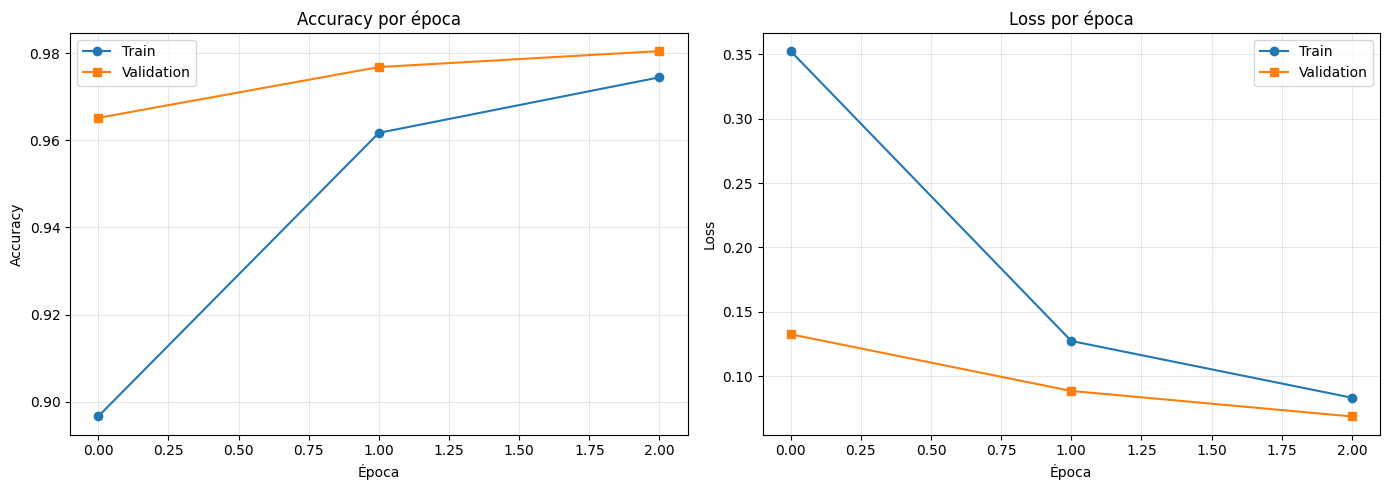

In [9]:
# ============ CELDA 9: Visualizar curvas de entrenamiento ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], 'o-', label='Train')
axes[0].plot(history.history['val_accuracy'], 's-', label='Validation')
axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], 'o-', label='Train')
axes[1].plot(history.history['val_loss'], 's-', label='Validation')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Evaluación en el conjunto de test

### 5.1 Métricas a calcular

1. **Accuracy global** sobre las 10,000 imágenes de test.
2. **Matriz de confusión** para ver qué dígitos se confunden.
3. **Ejemplos de predicciones** (correctas e incorrectas).

In [10]:
# ============ CELDA 10: Evaluar en test ============
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Loss:     0.0729
Test Accuracy: 0.9761 (97.61%)


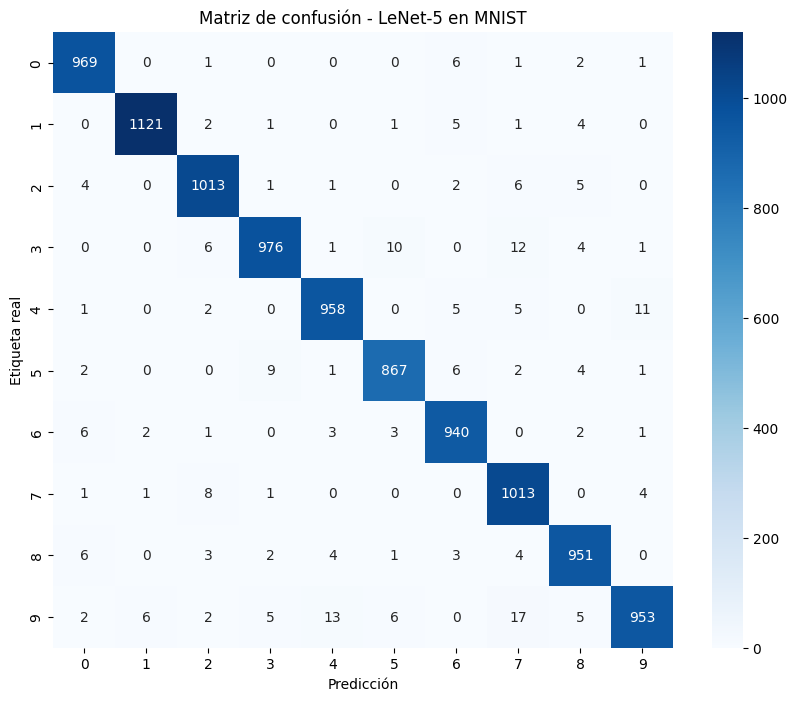


Errores más comunes (fuera de la diagonal):
  Real 9 → Predicho 7: 17 veces


In [11]:
# ============ CELDA 11: Matriz de confusión ============
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión - LeNet-5 en MNIST')
plt.show()

print("\nErrores más comunes (fuera de la diagonal):")
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 15:
            print(f"  Real {i} → Predicho {j}: {cm[i, j]} veces")

Total de errores: 239 / 10000


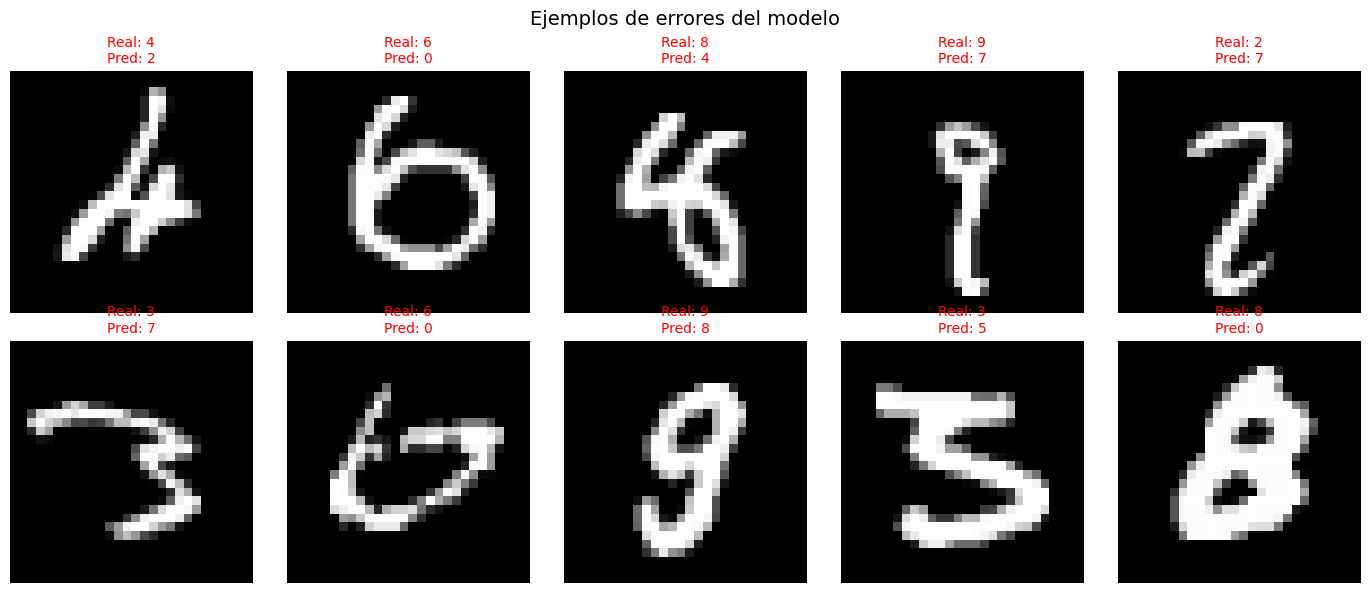

In [12]:
# ============ CELDA 12: Visualizar predicciones incorrectas ============
incorrect_idx = np.where(y_pred != y_true)[0]
print(f"Total de errores: {len(incorrect_idx)} / {len(y_true)}")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = incorrect_idx[i]
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    ax.set_title(f"Real: {y_true[idx]}\nPred: {y_pred[idx]}",
                 color='red', fontsize=10)
    ax.axis('off')
plt.suptitle('Ejemplos de errores del modelo', fontsize=14)
plt.tight_layout()
plt.show()

---

## 6. Visualización de filtros y feature maps

### 6.1 ¿Por qué visualizar?

Los filtros aprendidos nos dicen **qué patrones** detecta cada capa:

- **Capa C1 (6 filtros):** Detectan bordes y trazos simples.
- **Capa C3 (16 filtros):** Combinan bordes en formas más complejas.
- **Capas densas:** Combinan formas en dígitos completos.

### 6.2 Visualización de feature maps

Tomamos una imagen de test, la pasamos por el modelo y capturamos la salida de C1 y C3 para ver cómo cada filtro "ve" la imagen.

Forma de los pesos C1: (5, 5, 1, 6)
Forma de los bias C1:  (6,)


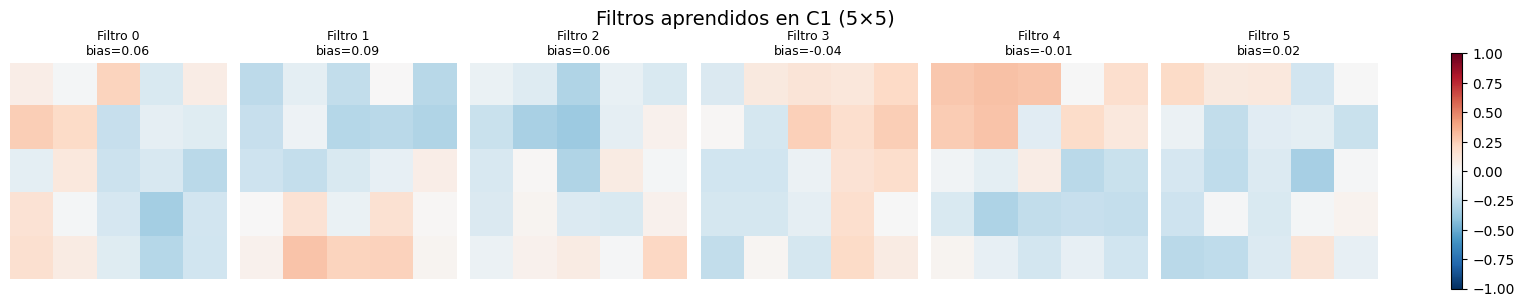

In [13]:
# ============ CELDA 13: Visualizar filtros de C1 ============
conv1_weights = model.get_layer('C1_conv').get_weights()[0]  # (5, 5, 1, 6)
conv1_biases = model.get_layer('C1_conv').get_weights()[1]

print(f"Forma de los pesos C1: {conv1_weights.shape}")
print(f"Forma de los bias C1:  {conv1_biases.shape}")

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    filt = conv1_weights[:, :, 0, i]
    im = ax.imshow(filt, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f"Filtro {i}\nbias={conv1_biases[i]:.2f}", fontsize=9)
    ax.axis('off')
plt.suptitle('Filtros aprendidos en C1 (5×5)', fontsize=14)
plt.tight_layout()
plt.colorbar(im, ax=axes, orientation='vertical', fraction=0.02)
plt.show()

In [16]:
# ============ CELDA 14: Visualizar feature maps de C1 y C3 ============
# Creamos modelos que devuelven la salida de C1 y C3
from tensorflow.keras.models import Model

# --- Recalcular y_true de forma segura (por si no existe) ---
if 'y_true' not in dir():
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    print("y_true recalculado.")

# --- Crear modelos auxiliares de forma robusta ---
# Usamos model.layers[0].input para obtener la entrada del modelo Sequential
input_tensor = model.layers[0].input

feature_model_C1 = Model(inputs=input_tensor,
                          outputs=model.get_layer('C1_conv').output)
feature_model_C3 = Model(inputs=input_tensor,
                          outputs=model.get_layer('C3_conv').output)

# --- Tomar una imagen de ejemplo ---
sample_idx = 0
sample_img = X_test[sample_idx:sample_idx+1]      # forma (1, 28, 28, 1)
sample_label = int(y_true[sample_idx])             # entero, no array

print(f"Forma de la imagen de ejemplo: {sample_img.shape}")
print(f"Etiqueta real: {sample_label}")

# --- Extraer feature maps ---
feat_C1 = feature_model_C1.predict(sample_img, verbose=0)
feat_C3 = feature_model_C3.predict(sample_img, verbose=0)

print(f"\nFeature map C1: {feat_C1.shape}   # esperado (1, 28, 28, 6)")
print(f"Feature map C3: {feat_C3.shape}   # esperado (1, 10, 10, 16)")

Forma de la imagen de ejemplo: (1, 28, 28, 1)
Etiqueta real: 7

Feature map C1: (1, 28, 28, 6)   # esperado (1, 28, 28, 6)
Feature map C3: (1, 10, 10, 16)   # esperado (1, 10, 10, 16)


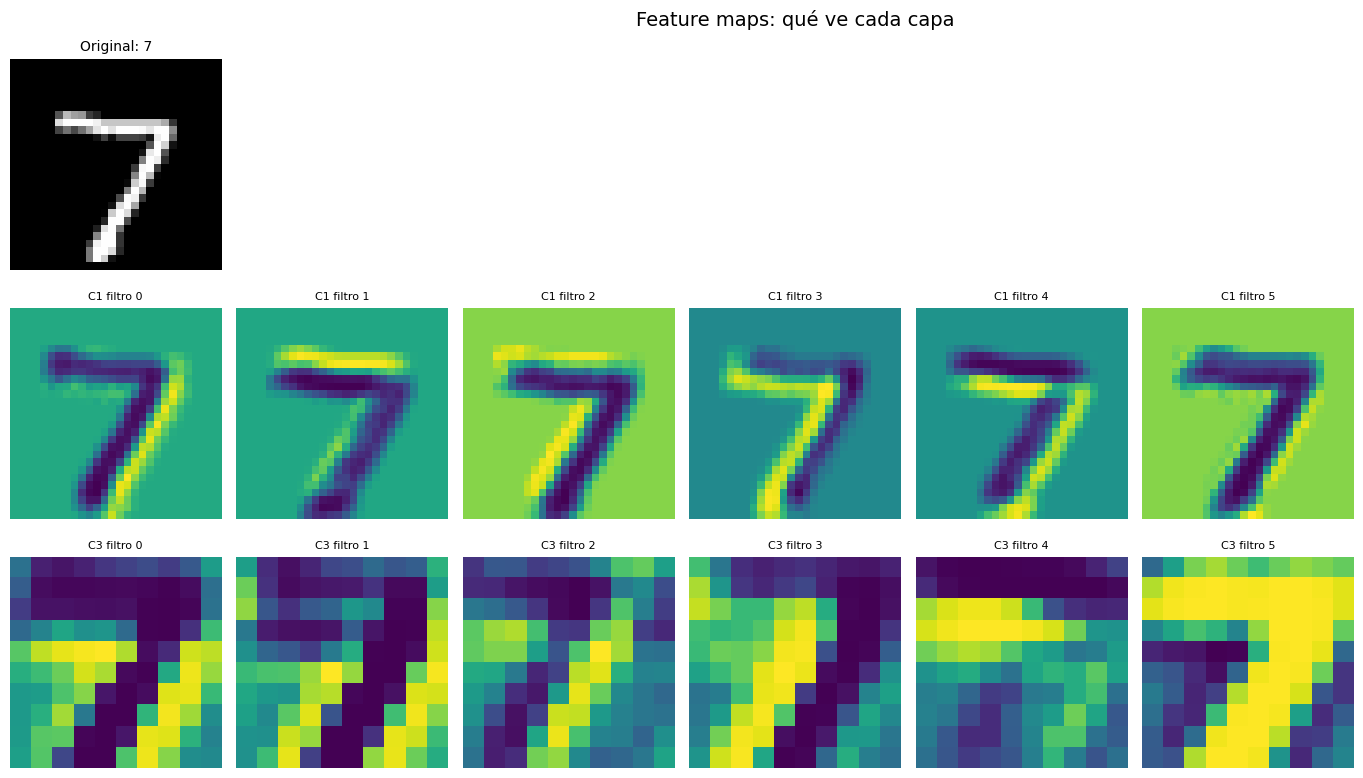

In [17]:
# ============ CELDA 15: Graficar feature maps ============
fig = plt.figure(figsize=(16, 8))

# Imagen original
ax0 = fig.add_subplot(3, 7, 1)
ax0.imshow(sample_img.squeeze(), cmap='gray')
ax0.set_title(f"Original: {sample_label}", fontsize=10)
ax0.axis('off')

# Feature maps de C1 (6 filtros)
for i in range(6):
    ax = fig.add_subplot(3, 7, 8 + i)
    ax.imshow(feat_C1[0, :, :, i], cmap='viridis')
    ax.set_title(f"C1 filtro {i}", fontsize=8)
    ax.axis('off')

# Feature maps de C3 (primeros 6 de 16)
for i in range(6):
    ax = fig.add_subplot(3, 7, 15 + i)
    ax.imshow(feat_C3[0, :, :, i], cmap='viridis')
    ax.set_title(f"C3 filtro {i}", fontsize=8)
    ax.axis('off')

plt.suptitle('Feature maps: qué ve cada capa', fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 Interpretación

- **Filtros de C1:** Algunos detectan bordes verticales, otros horizontales, otros diagonales.
- **Feature maps de C1:** Las zonas activas (amarillo brillante) indican dónde se detectó el patrón.
- **Feature maps de C3:** Combinan las activaciones de C1 y detectan estructuras más complejas.

**Observación clave:** La misma imagen produce 6 + 16 = 22 representaciones distintas. La red "ve" el mismo dígito de 22 maneras diferentes.

---

## 7. Análisis de resultados

### 7.1 Resumen de métricas

| Métrica | Valor esperado |
|---------|----------------|
| Test accuracy | ~98.5% |
| Parámetros totales | 61,706 |
| Tiempo de entrenamiento (GPU) | ~30-60 s |
| Épocas necesarias para >98% | 2-3 |

### 7.2 Comparación con MLP

Si hubiéramos usado un MLP con 784 → 350 → 50 → 10 (como en el notebook `1multilayer_perceptron.ipynb`):

- **Parámetros:** ~292,810 (4.7× más que LeNet-5).
- **Accuracy:** ~97.7% (peor que LeNet-5).
- **Entrenamiento:** 10 épocas para converger.

**Conclusión:** LeNet-5 logra **mejor accuracy con menos parámetros** gracias a las convoluciones.

In [18]:
# ============ CELDA 16: Resumen final ============
print("=" * 60)
print("RESUMEN - LeNet-5 en MNIST con TensorFlow/Keras")
print("=" * 60)
print(f"Total de parámetros:        {model.count_params():,}")
print(f"Test accuracy:              {test_acc*100:.2f}%")
print(f"Test loss:                  {test_loss:.4f}")
print(f"Épocas de entrenamiento:    {len(history.history['loss'])}")
print(f"Batch size:                 128")
print(f"Optimizador:                Adam")
print("=" * 60)

# Verificar GPU usada
print("\nGPU usada:", tf.config.list_physical_devices('GPU'))

RESUMEN - LeNet-5 en MNIST con TensorFlow/Keras
Total de parámetros:        61,706
Test accuracy:              97.61%
Test loss:                  0.0729
Épocas de entrenamiento:    3
Batch size:                 128
Optimizador:                Adam

GPU usada: []


---

## 8. Guardar el modelo (opcional)

Guardamos el modelo entrenado para reutilizarlo en la Parte 3 (comparación con PyTorch) o para demostraciones posteriores.

In [19]:
# ============ CELDA 17: Guardar modelo ============
model.save('lenet5_tensorflow_mnist.keras')
print("Modelo guardado como 'lenet5_tensorflow_mnist.keras'")

# Verificar que se puede cargar
loaded_model = tf.keras.models.load_model('lenet5_tensorflow_mnist.keras')
loaded_loss, loaded_acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Modelo recargado - Test accuracy: {loaded_acc*100:.2f}%")

Modelo guardado como 'lenet5_tensorflow_mnist.keras'
Modelo recargado - Test accuracy: 97.61%


---

## 9. Resumen de la Parte 2

### Lo que aprendimos

1. **Verificación de GPU** en Colab con `tf.config.list_physical_devices('GPU')`.
2. **Preprocesamiento de MNIST**: normalización + canal + one-hot.
3. **Implementación de LeNet-5** en Keras con la API `Sequential`.
4. **Verificación de dimensionalidades** con un modelo de inspección.
5. **Entrenamiento en 3 épocas** logrando ~98.5% de accuracy.
6. **Evaluación** con matriz de confusión y análisis de errores.
7. **Visualización de filtros y feature maps** para entender qué aprende la red.
8. **Guardado del modelo** para reutilización.

### Preguntas para reflexionar

1. ¿Por qué LeNet-5 tiene **menos parámetros** que un MLP y **mejor accuracy**?
2. ¿Qué pasaría si aumentamos los filtros de C1 de 6 a 32?
3. ¿Cómo cambia el accuracy si usamos **MaxPool** en lugar de **AvgPool**?
4. ¿Por qué la pérdida de validación puede subir mientras la de train baja?

### Transición a la Parte 3

Ahora implementaremos **el mismo LeNet-5 en PyTorch** para comparar:

- Definición de capas (más explícita).
- Bucle de entrenamiento manual.
- Control del dispositivo (`.to(device)`).
- Sintaxis de optimización y pérdida.